In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../pyCudaPolygon"))
import pyCudaPolygon as pcp
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.animation import FuncAnimation
from pyCudaPolygonLink import libpyCudaPolygon as lpcp

In [2]:
maxSteps = 20

In [3]:
def h(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = r2 - r1
    return pref * (r1[0] + r2[0]) * d[1] - lam * np.sqrt(np.sum(d**2))

In [4]:
def g12(pt1, pt2, startPoint, lam, pref):
    r1 = pt1 - startPoint + 1.5
    r2 = pt2 - startPoint + 1.5
    r1 %= 1
    r2 %= 1
    r1 -= 0.5
    r2 -= 0.5
    d = pt2 - pt1 + 1.5
    d %= 1
    d -= 0.5
    lambd = lam * d / np.sqrt(np.sum(d**2))
    g1x = pref * d[1] + lambd[0]
    g1y = -pref * (r1[0] + r2[0]) + lambd[1]
    g2x = pref * d[1] - lambd[0]
    g2y = pref * (r1[0] + r2[0]) - lambd[1]
    return np.array([g1x, g1y]), np.array([g2x, g2y])

2.220446049250313e-16


<Figure size 640x480 with 0 Axes>

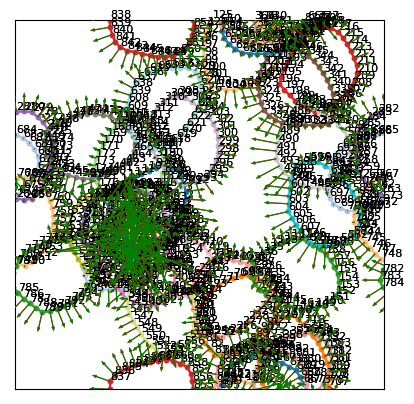

In [5]:
lam = 0.0
pref = 1
numPolygons = 30
n = 32
nVals = [0, 1, 2, 3, 9,4 ,5, 6, 20, 25, 35, 54]
i = 7
phi = 1.0
kappa = 3.65
m = pcp.model(size = n * numPolygons, seed = i)
m.setModelEnum("normal")
m.generateRandomPolygons(numPolygons, n, kappa = kappa, phi = phi)
positions = m.getPositions()
positions[1::2] += 0.4
positions %= 1
m.setPositions(positions)
#modelDir = "minCheckpointRestart2/" + str(np.max(np.array(os.listdir("minCheckpointRestart2")).astype(int)))
#m.loadModel(modelDir)
plt.clf()
# Works fine
m.setMaxEdgeLength()
# use default max edge length by finding it within the simulation
# You can adjust this later.
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0.01)
m.updateContacts()
m.updateOutersections()
m.updateForceEnergy()
forceTest = m.getForces()
forceTest0 = m.getConstrainedForce(forceTest)
overlapArea, force = m.functional(h, g12 = g12, lam = lam, pref = pref)
print(np.max(np.abs(force - forceTest)))
force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()
fig, ax = plt.subplots()
artists = m.draw(ax = ax, forces = force0, arrowColor = 'r', numbering = True)
artists2 = m.draw(ax = ax, forces = forceTest0, arrowColor = 'g', numbering = True)

0.999941555037411
0.23521093372522284 -0.8749343528152804
0.459705114364624 0.8398540616035461
0.4106249819808909 0.4048445568293042
0.4106249819808909 0.4048445568293042
[[ 9  0  3  3]
 [ 5  0  7 29]
 [25  0 15 10]
 [28  0 15 16]
 [16  0 16 15]
 [29  0 18  8]
 [ 1  0 19 28]
 [12  0 20  2]
 [13  0 22 14]
 [24  1  1  1]
 [12  1 10 12]
 [17  1 11 30]
 [13  1 12 21]
 [29  1 15 21]
 [25  1 19 28]
 [28  1 20  5]
 [ 0  1 20 28]
 [16  1 26 12]
 [ 7  2  0  9]
 [ 4  2 30 15]
 [10  3 12  1]
 [20  3 17 19]
 [27  3 18  7]
 [11  3 18 18]
 [ 7  4  9 13]
 [ 2  4 10  3]
 [14  5  6 21]
 [25  5 17 11]
 [16  5 17 16]
 [28  5 17 17]
 [ 0  5 18 16]
 [29  5 20  6]
 [ 9  5 28 31]
 [19  5 31  8]
 [15  6  7  4]
 [10  6 31 26]
 [ 4  7  8 14]
 [13  7 18  1]
 [17  7 23 19]
 [ 2  7 27 13]
 [23  8  5  0]
 [14  8 15  4]
 [21  8 30 16]
 [19  9 17 16]
 [ 5  9 26  1]
 [ 0  9 31  8]
 [15 10  9  7]
 [ 6 10 17 12]
 [20 10 28 20]
 [ 3 10 29 17]
 [22 11  1 10]
 [27 11  7 20]
 [20 11  9  1]
 [ 3 11 13 22]
 [22 11 23  0]
 [16

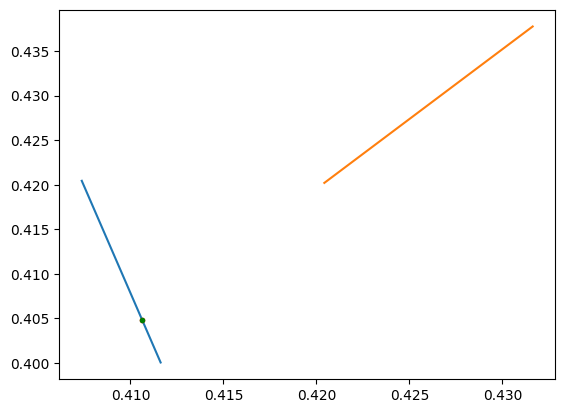

In [6]:
# 18 and 62
positions = m.getPositions()
print(np.max(positions))
xi1 = positions[52 * 2]
yi1 = positions[52 * 2 + 1]
xi2 = positions[53 * 2]
yi2 = positions[53 * 2 + 1]
xj1 = positions[29 * 2]
yj1 = positions[29 * 2 + 1]
xj2 = positions[30 * 2]
yj2 = positions[30 * 2 + 1]
# Now get the r vector (for i)
rx = (xi2 - xi1 + 1.5) % 1 - 0.5
ry = (yi2 - yi1 + 1.5) % 1 - 0.5
# And then s (for j):
sx = (xj2 - xj1 + 1.5) % 1 - 0.5
sy = (yj2 - yj1 + 1.5) % 1 - 0.5
# now g
gx = (xj1 - xi1 + 1.5) % 1 - 0.5
gy = (yj1 - yi1 + 1.5) % 1 - 0.5
denom = rx * sy - ry * sx
tt = (gx * sy - gy * sx) / denom
uu = (gx * ry - gy * rx) / denom
tu = m.getTU()
print(tt, uu)
print(tu[0], tu[1])
print(xi1 + tt * rx, yi1 + tt * ry)
print(xj1 + uu * sx, yj1 + uu * sy)
plt.plot([xi1, xi2], [yi1, yi2])
plt.plot([xj1, xj2], [yj1, yj2])
plt.plot([xi1 + tt * rx], [yi1 + tt * ry], ".r")
plt.plot([xj1 + uu * sx], [yj1 + uu * sy], ".g")
print(m.unpackIntersections(), m.getTU())
print(m.unpackOutersections(), m.getUT())

In [7]:
m.getUT()

array([0.16431908, 0.37122458, 0.68257761, 0.22513367, 0.01671646,
       0.05372539, 0.44809732, 0.3714413 , 0.85764039, 0.16592993,
       0.22773871, 0.83085752, 0.21841584, 0.37407404, 0.38688836,
       0.65527278, 0.50494903, 0.43702891, 0.34153497, 0.35848644,
       0.05757476, 0.67758691, 0.5694536 , 0.22653529, 0.35238236,
       0.39756078, 0.02793883, 0.07507587, 0.31379479, 0.46985981,
       0.93589771, 0.48328644, 0.46171078, 0.50040156, 0.87569857,
       0.28745618, 0.57280844, 0.25460449, 0.62783021, 0.86792201,
       0.34193903, 0.19529887, 0.89165562, 0.0195888 , 0.0749401 ,
       0.29159072, 0.86048228, 0.40179807, 0.53203809, 0.24757683,
       0.46972692, 0.90900272, 0.63341188, 0.52605772, 0.90285575,
       0.99748266, 0.811499  , 0.03089234, 0.57224357, 0.45099074,
       0.00431024, 0.88167661, 0.09523382, 0.67057735, 0.69042271,
       0.79417431, 0.30650973, 0.16593663, 0.71940917, 0.79318488,
       0.48772475, 0.34838948, 0.37198052, 0.49896693, 0.81972

In [8]:
m.getTU()

array([0.45970511, 0.83985406, 0.00431024, 0.88167661, 0.36294904,
       0.46228546, 0.57365829, 0.41797176, 0.85081303, 0.40035525,
       0.00243708, 0.78690195, 0.46171078, 0.50040156, 0.20348799,
       0.25955579, 0.82713586, 0.85428441, 0.51686817, 0.32367331,
       0.33407822, 0.30536684, 0.56649959, 0.78599763, 0.01084528,
       0.62541717, 0.2594507 , 0.4613474 , 0.14288059, 0.65826011,
       0.2072546 , 0.50623745, 0.21841584, 0.37407404, 0.11434972,
       0.35012317, 0.55790943, 0.71024042, 0.46972692, 0.90900272,
       0.86232418, 0.55995578, 0.78415322, 0.13183896, 0.05603744,
       0.91016716, 0.21026403, 0.37167111, 0.37198052, 0.49896693,
       0.62783021, 0.86792201, 0.45174125, 0.34643707, 0.58362496,
       0.48134774, 0.33820668, 0.74059284, 0.96653712, 0.08894117,
       0.68257761, 0.22513367, 0.09346204, 0.63399225, 0.70988446,
       0.72300851, 0.34562576, 0.46080685, 0.09152331, 0.46456677,
       0.88915718, 0.01548532, 0.53203809, 0.24757683, 0.44241

In [9]:
overlapArea

1.4034078350359085

In [10]:
si = (m.getIntersections() >> 48) & 0xFFFF
sj = (m.getIntersections() >> 32) & 0xFFFF
j = (m.getIntersections() >> 16) & 0xFFFF
i = (m.getIntersections()) & 0xFFFF

In [11]:
startPos = m.getPositions()
m.minimizeGD(h = h, g12 = g12, lam = lam, pref = pref, maxSteps = maxSteps, dt = 0.001, progressBar = True, checkpointDir = "forceTestingCUDACOMP2", checkpointFreq = 1)
m.initializeNeighborCells()
m.updateNeighborCells()
m.updateNeighbors(0.01)
m.updateContacts()
m.updatePlayers()
overlapArea, force = m.functional(h = h, g12 = g12, lam = lam, pref = pref)
force0 = m.getConstrainedForce(force)
positions0 = m.getPositions()

TypeError: minimizeGD() got an unexpected keyword argument 'h'

In [ ]:
artists = m.draw(forces = force0, arrowColor = 'r')

In [ ]:
np.max(np.abs(force0))

In [ ]:
#m.loadModel("squishsquish10v6")

In [ ]:
#m.getPositions()

In [ ]:
m.saveModel("squishsquish10v7")

In [ ]:
m.updateAreas()
areas = m.getAreas()
print(areas, np.std(areas), np.std(areas) / np.mean(areas))

In [ ]:
# It only drifted by about 1% which is pretty remarkable actually

In [ ]:
edges = m.getEdgeLengths()
l0 = np.sqrt(phi / m.getNumPolygons()) * kappa / m.getnArray()
edges = (edges.reshape(len(edges) // 32, 32).T / l0).T
print(np.std(edges, axis = 1) / np.mean(edges, axis = 1))